In [1]:
#Cell 1 — load data + the Random Forest model from Step 5:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import joblib

from src.utils import load_config, set_seed
from src.preprocessing.feature_selection import (
    find_correlated_features, select_top_k_by_importance,
    apply_feature_selection, print_selection_report
)
from src.models.advanced import train_random_forest
from src.evaluation.metrics import evaluate_model, print_metrics, results_to_dataframe

cfg = load_config()
set_seed(cfg["project"]["random_state"])
processed_dir = cfg["paths"]["processed_dir"]
models_dir = cfg["paths"]["models_dir"]

X_train_raw = pd.read_parquet(os.path.join(processed_dir, "X_train_raw.parquet"))
X_test_raw = pd.read_parquet(os.path.join(processed_dir, "X_test_raw.parquet"))
y_train = pd.read_parquet(os.path.join(processed_dir, "y_train.parquet"))["label_binary"]
y_test = pd.read_parquet(os.path.join(processed_dir, "y_test.parquet"))["label_binary"]

rf_model = joblib.load(os.path.join(models_dir, "random_forest.joblib"))

print("Data loaded:", X_train_raw.shape)
print("RF model loaded.")

Data loaded: (178464, 67)
RF model loaded.


In [2]:
#Cell 2 — correlation analysis (train data only):
corr_result = find_correlated_features(X_train_raw, threshold=0.95)

print(f"Found {len(corr_result['correlated_pairs'])} correlated pairs (>0.95):\n")
for f1, f2, corr_val in corr_result["correlated_pairs"][:20]:
    print(f"  {f1}  <->  {f2}   (corr = {corr_val})")

if len(corr_result["correlated_pairs"]) > 20:
    print(f"  ... and {len(corr_result['correlated_pairs']) - 20} more pairs")

print(f"\nRecommended to drop ({len(corr_result['recommended_drop'])} features):")
print(corr_result["recommended_drop"])

Found 45 correlated pairs (>0.95):

  Total Fwd Packets  <->  Total Backward Packets   (corr = 0.9572)
  Total Backward Packets  <->  Total Length of Bwd Packets   (corr = 0.9684)
  Fwd Packet Length Max  <->  Fwd Packet Length Std   (corr = 0.9917)
  Bwd Packet Length Max  <->  Bwd Packet Length Mean   (corr = 0.9613)
  Bwd Packet Length Max  <->  Bwd Packet Length Std   (corr = 0.9927)
  Bwd Packet Length Mean  <->  Bwd Packet Length Std   (corr = 0.9559)
  Flow IAT Std  <->  Flow IAT Max   (corr = 0.9782)
  Flow Duration  <->  Fwd IAT Total   (corr = 0.9971)
  Flow IAT Max  <->  Fwd IAT Std   (corr = 0.9719)
  Flow IAT Std  <->  Fwd IAT Max   (corr = 0.9695)
  Flow IAT Max  <->  Fwd IAT Max   (corr = 0.9953)
  Fwd IAT Std  <->  Fwd IAT Max   (corr = 0.9807)
  Bwd IAT Std  <->  Bwd IAT Max   (corr = 0.9594)
  Total Fwd Packets  <->  Fwd Header Length   (corr = 0.9665)
  Total Backward Packets  <->  Bwd Header Length   (corr = 0.9752)
  Fwd Header Length  <->  Bwd Header Length   (cor

Figure saved: d:\MSc_Project\Network_IDS_Framework\results/figures\correlation_matrix.png


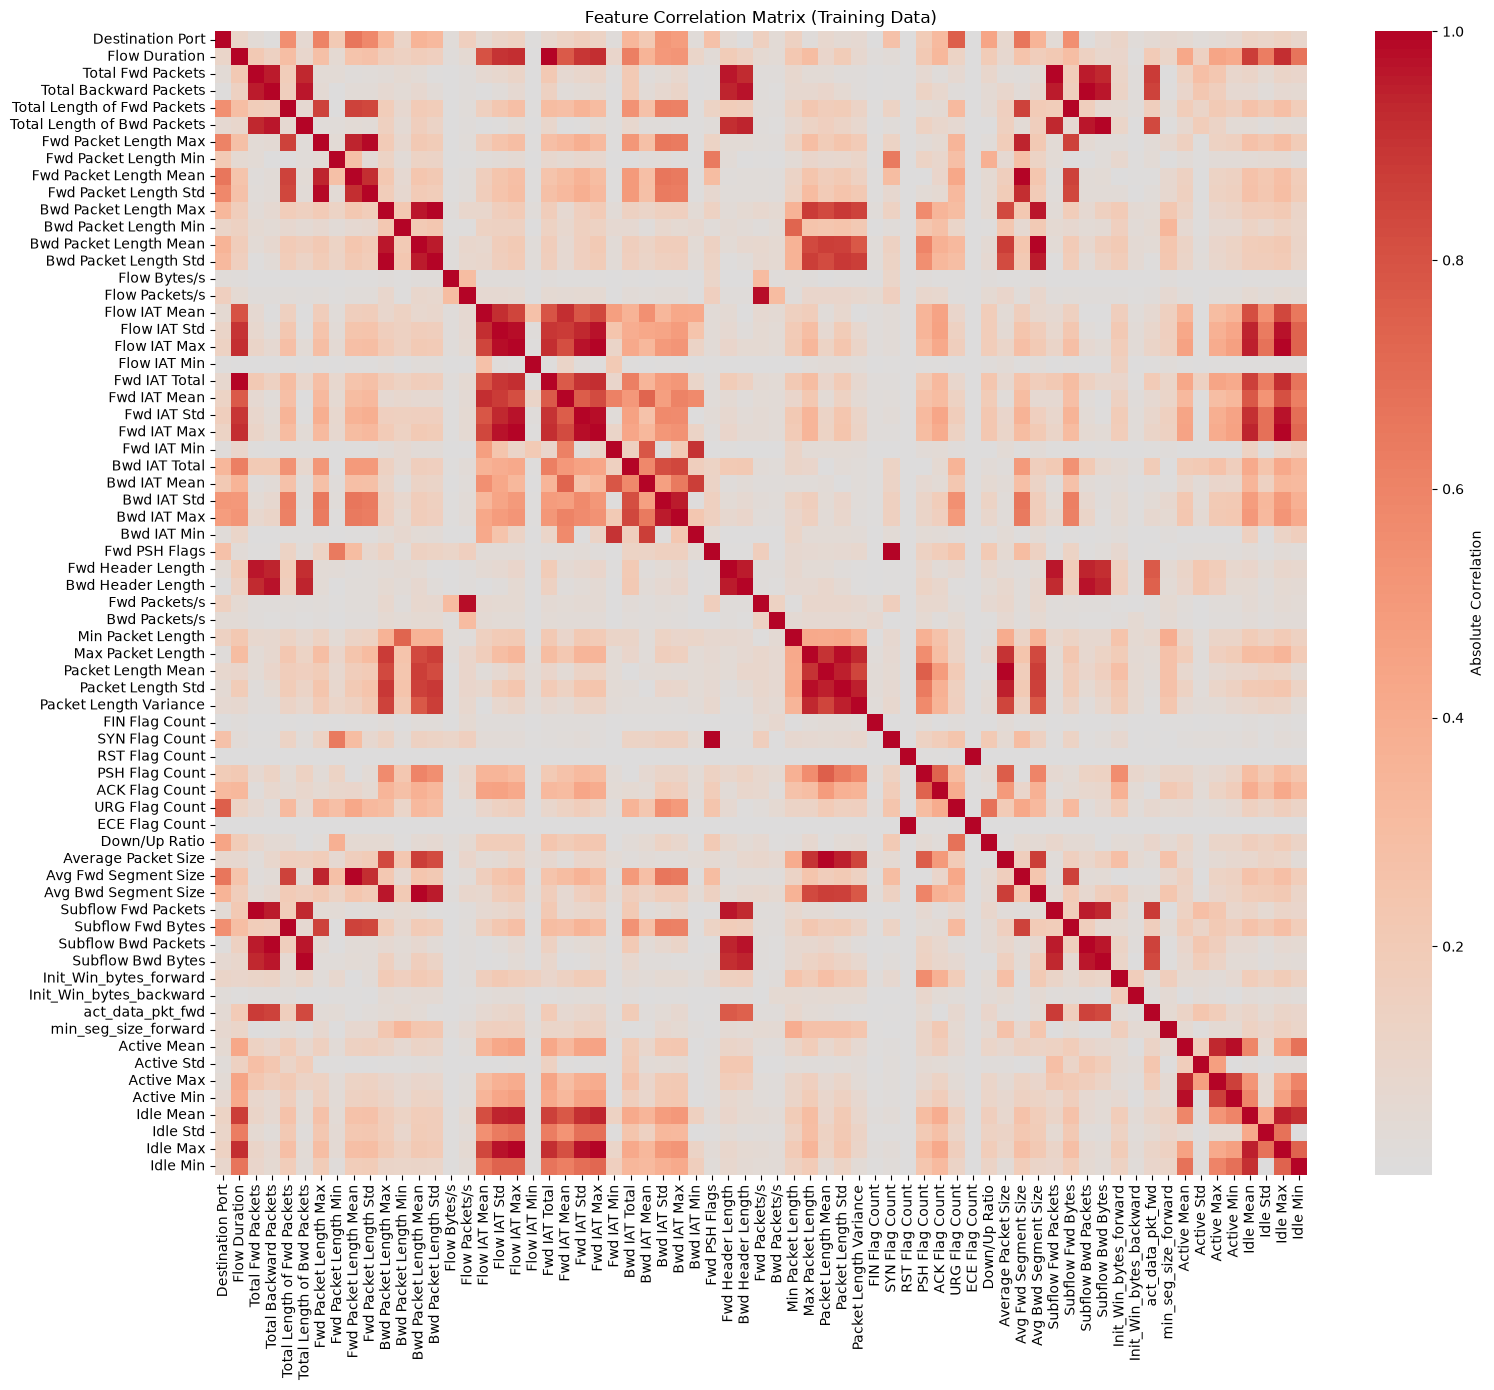

In [3]:
#Cell 3 — visualize the correlation matrix (optional but good for thesis figures):
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_result["correlation_matrix"], cmap="coolwarm", center=0,
           cbar_kws={"label": "Absolute Correlation"}, ax=ax,
           xticklabels=True, yticklabels=True)
ax.set_title("Feature Correlation Matrix (Training Data)")
plt.tight_layout()

from src.utils import save_figure
save_figure(fig, "correlation_matrix.png", cfg)
plt.show()

In [4]:
#Cell 4 — remove correlated features, recompute RF importance on the reduced set:
features_after_corr = [c for c in X_train_raw.columns if c not in corr_result["recommended_drop"]]

X_train_reduced = X_train_raw[features_after_corr]
X_test_reduced = X_test_raw[features_after_corr]

print(f"Features after correlation removal: {len(features_after_corr)} "
      f"(was {X_train_raw.shape[1]})")

# Retrain RF on the reduced feature set to get importance scores that
# reflect THIS feature set (not biased by the dropped correlated duplicates)
seed = cfg["project"]["random_state"]
rf_reduced, _ = train_random_forest(X_train_reduced, y_train, random_state=seed)

importances = pd.Series(rf_reduced.feature_importances_, index=features_after_corr)
importances = importances.sort_values(ascending=False)

print("\nTop 20 features by importance (post-correlation-removal):")
print(importances.head(20))

Features after correlation removal: 42 (was 67)

Top 20 features by importance (post-correlation-removal):
Fwd Packet Length Max          0.106102
Total Length of Fwd Packets    0.102120
Destination Port               0.101765
Init_Win_bytes_forward         0.092006
act_data_pkt_fwd               0.082660
Bwd Packet Length Max          0.081461
Fwd Packet Length Mean         0.065949
Total Fwd Packets              0.060858
Bwd Packet Length Min          0.048588
Init_Win_bytes_backward        0.040046
Fwd IAT Mean                   0.028180
Flow IAT Std                   0.023604
Bwd IAT Total                  0.020411
Bwd Packets/s                  0.019189
Max Packet Length              0.017937
Packet Length Mean             0.015568
Bwd IAT Mean                   0.011371
URG Flag Count                 0.010253
Packet Length Variance         0.010199
Fwd Packet Length Min          0.009410
dtype: float64


In [5]:
#Cell 5 — select top-K, run before/after comparison:
K = 20  # defensible round number; keeps model fast and interpretable for SHAP later

selected_features = select_top_k_by_importance(importances, k=K)

X_train_selected, X_test_selected = apply_feature_selection(
    X_train_reduced, X_test_reduced, selected_features
)

print_selection_report(
    n_original=X_train_raw.shape[1],
    dropped_correlated=corr_result["recommended_drop"],
    n_after_correlation=len(features_after_corr),
    k_selected=K,
    final_features=selected_features,
)

# --- Train RF on FULL feature set (baseline for comparison) ---
rf_full, rf_full_time = train_random_forest(X_train_raw, y_train, random_state=seed)
metrics_full = evaluate_model(rf_full, X_test_raw, y_test, model_name=f"RF - All {X_train_raw.shape[1]} features")
metrics_full["train_time_sec"] = round(rf_full_time, 4)

# --- Train RF on SELECTED feature set ---
rf_selected, rf_selected_time = train_random_forest(X_train_selected, y_train, random_state=seed)
metrics_selected = evaluate_model(rf_selected, X_test_selected, y_test, model_name=f"RF - Selected {K} features")
metrics_selected["train_time_sec"] = round(rf_selected_time, 4)

print_metrics(metrics_full)
print_metrics(metrics_selected)

comparison = results_to_dataframe([metrics_full, metrics_selected])
print("\nBEFORE vs AFTER feature selection:")
print(comparison[["model", "accuracy", "f1", "roc_auc", "train_time_sec", "prediction_time_sec"]])

FEATURE SELECTION REPORT
Original features:                67
Removed (correlation > 0.95):      25
    - Active Min
    - Average Packet Size
    - Avg Bwd Segment Size
    - Avg Fwd Segment Size
    - Bwd Header Length
    - Bwd IAT Max
    - Bwd Packet Length Mean
    - Bwd Packet Length Std
    - ECE Flag Count
    - Flow IAT Max
    - Fwd Header Length
    - Fwd IAT Max
    - Fwd IAT Std
    - Fwd IAT Total
    - Fwd Packet Length Std
    - Fwd Packets/s
    - Idle Max
    - Packet Length Std
    - SYN Flag Count
    - Subflow Bwd Bytes
    - Subflow Bwd Packets
    - Subflow Fwd Bytes
    - Subflow Fwd Packets
    - Total Backward Packets
    - Total Length of Bwd Packets
Remaining after correlation step:  42
Top-K selected by RF importance:   20
----------------------------------------------------------------
Final selected features:
    - Fwd Packet Length Max
    - Total Length of Fwd Packets
    - Destination Port
    - Init_Win_bytes_forward
    - act_data_pkt_fwd
    - Bwd 

In [6]:
#Cell 6 — save everything:
import json

metrics_dir = cfg["paths"]["metrics_dir"]
reports_dir = cfg["paths"]["reports_dir"]

comparison.to_csv(os.path.join(metrics_dir, "feature_selection_comparison.csv"), index=False)

X_train_selected.to_parquet(os.path.join(processed_dir, "X_train_selected.parquet"))
X_test_selected.to_parquet(os.path.join(processed_dir, "X_test_selected.parquet"))

with open(os.path.join(reports_dir, "selected_features.json"), "w") as f:
    json.dump({
        "correlation_threshold": 0.95,
        "dropped_correlated_features": corr_result["recommended_drop"],
        "k_selected": K,
        "selected_features": selected_features,
    }, f, indent=2)

joblib.dump(rf_selected, os.path.join(models_dir, "random_forest_selected_features.joblib"))

print("Saved selected feature train/test sets, comparison table, and model.")
print(f"\nFinal feature count: {len(selected_features)} (down from {X_train_raw.shape[1]})")

Saved selected feature train/test sets, comparison table, and model.

Final feature count: 20 (down from 67)
